# Supply Chain & Logistics Analytics

## Notebook 3 - Business Insights & Recommendations

The objective of this notebook is to convert analytical findings into business decisions. The analysis focuses on revenue generation, inventory optimization, logistics performance, and actionable recommendations that can support operational decision-making.

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Datasets

In [6]:
customers = pd.read_csv("../Dataset/customers.csv")
orders = pd.read_csv("../Dataset/orders.csv")
products = pd.read_csv("../Dataset/products.csv")
suppliers = pd.read_csv("../Dataset/suppliers.csv")
warehouses = pd.read_csv("../Dataset/warehouses.csv")
inventory = pd.read_csv("../Dataset/inventory.csv")
shipments = pd.read_csv("../Dataset/shipments.csv")
returns = pd.read_csv("../Dataset/returns.csv")

In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

shipments["delivery_date"] = pd.to_datetime(
    shipments["delivery_date"]
)

# Block 1 - Revenue Analysis

This section identifies the products, categories, and customer segments that contribute the most revenue to the business.

### Q1. Which products generate the highest revenue?

,Total_Revenue
product_name,
Product_68,1321556.41
Product_118,1278281.70
Product_106,1225609.63
Product_23,1188086.25
Product_5,1124659.17
Product_47,1122949.32
Product_8,1121113.94
Product_57,1103183.27
Product_51,1084173.34


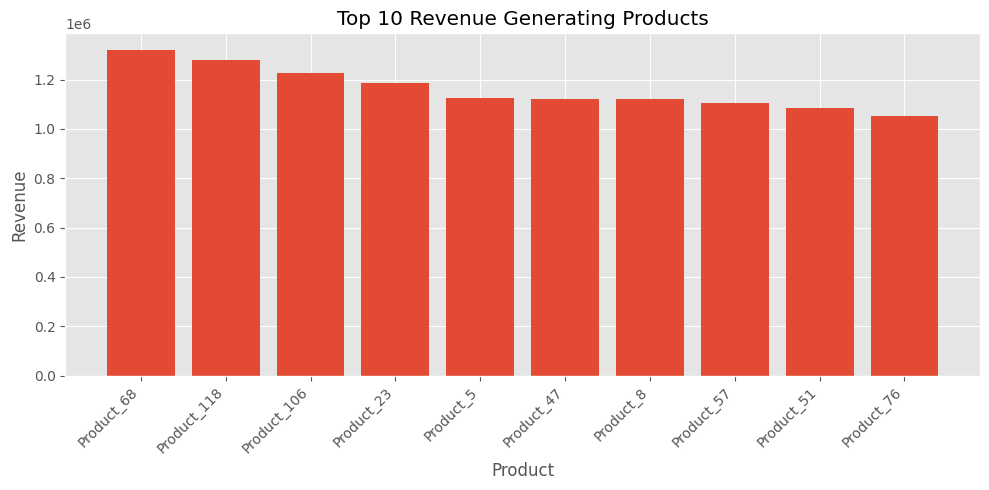


Business Insight: Product_68 generated the highest revenue.
Recommendation: Maintain sufficient inventory and prioritize marketing for this product.


In [10]:
# Revenue for each order
orders["revenue"] = (
    orders["quantity"] *
    orders["unit_price"]
)

# Revenue by product
product_revenue = (
    orders
    .merge(products, on="product_id")
    .groupby("product_name")
    .agg(
        Total_Revenue=("revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

display(product_revenue)

plt.figure(figsize=(10,5))

plt.bar(
    product_revenue.index,
    product_revenue["Total_Revenue"]
)

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

print(
    f"\nBusiness Insight: {product_revenue.index[0]} generated the highest revenue."
)

print(
    "Recommendation: Maintain sufficient inventory and prioritize marketing for this product."
)

### Q2. Which product categories contribute the highest revenue?

,Total_Revenue
category,
Sports,17939557.00
Home,13148131.91
Furniture,11468219.84
Office,11183543.10
Electronics,9711304.16


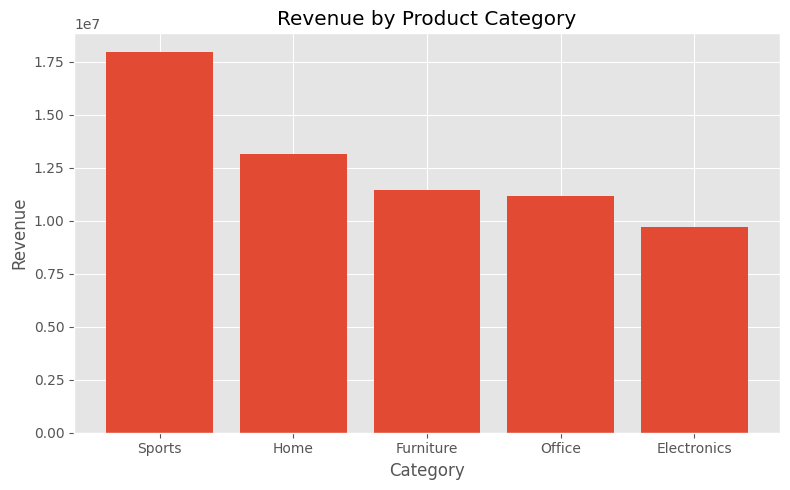


Business Insight: Sports contributes the highest revenue.
Recommendation: Expand high-performing product categories and monitor low-performing categories.


In [12]:
category_revenue = (
    orders
    .merge(products, on="product_id")
    .groupby("category")
    .agg(
        Total_Revenue=("revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(category_revenue)

plt.figure(figsize=(8,5))

plt.bar(
    category_revenue.index,
    category_revenue["Total_Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

print(
    f"\nBusiness Insight: {category_revenue.index[0]} contributes the highest revenue."
)

print(
    "Recommendation: Expand high-performing product categories and monitor low-performing categories."
)

### Q3. Which customer segment generates the highest revenue?

,Total_Revenue
segment,
Retail,24213897.12
Corporate,20969353.30
Wholesale,18267505.59


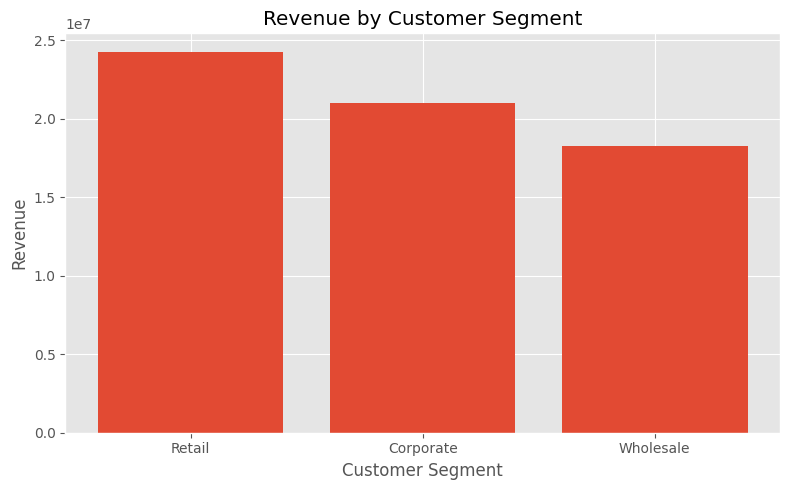


Business Insight: Retail customers generate the highest revenue.
Recommendation: Focus retention campaigns and personalized offers on this customer segment.


In [14]:
segment_revenue = (
    orders
    .merge(customers, on="customer_id")
    .groupby("segment")
    .agg(
        Total_Revenue=("revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(segment_revenue)

plt.figure(figsize=(8,5))

plt.bar(
    segment_revenue.index,
    segment_revenue["Total_Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

print(
    f"\nBusiness Insight: {segment_revenue.index[0]} customers generate the highest revenue."
)

print(
    "Recommendation: Focus retention campaigns and personalized offers on this customer segment."
)

# Block 2 - Inventory Decision Analysis

This section identifies inventory-related issues and provides recommendations for improving stock availability and warehouse efficiency.

### Q4. Which products should be restocked immediately?

In [18]:
restock_products = (
    inventory
    .merge(products, on="product_id")
)

restock_products = restock_products[
    restock_products["stock_qty"] <= restock_products["reorder_level"]
]

restock_products = (
    restock_products[
        [
            "product_name",
            "warehouse_id",
            "stock_qty",
            "reorder_level"
        ]
    ]
    .sort_values("stock_qty")
)

display(restock_products)

print(f"\nProducts requiring immediate restocking: {len(restock_products)}")

print(
    "\nBusiness Insight: These products have reached or fallen below their reorder level."
)

print(
    "Recommendation: Raise purchase orders immediately to avoid future stock-outs."
)

,product_name,warehouse_id,stock_qty,reorder_level
8,Product_2,1,21,182
662,Product_83,7,22,108
393,Product_50,2,22,178
183,Product_23,8,24,191
336,Product_43,1,26,290
...,...,...,...,...
274,Product_35,3,269,288
839,Product_105,8,278,286
136,Product_18,1,283,293
57,Product_8,2,287,299



Products requiring immediate restocking: 243

Business Insight: These products have reached or fallen below their reorder level.
Recommendation: Raise purchase orders immediately to avoid future stock-outs.


### Q5. Which warehouses require inventory redistribution?

,warehouse_city,capacity,Total_Stock,Utilization (%)
0,Ahmedabad,16452,43339,263.426939
1,Bengaluru,10924,47717,436.808861
2,Chennai,7945,45231,569.301447
3,Delhi,14593,48074,329.431919
4,Hyderabad,9911,47313,477.378670
5,Kolkata,9070,48234,531.797133
6,Mumbai,12424,50472,406.245976
7,Pune,18015,49909,277.041354


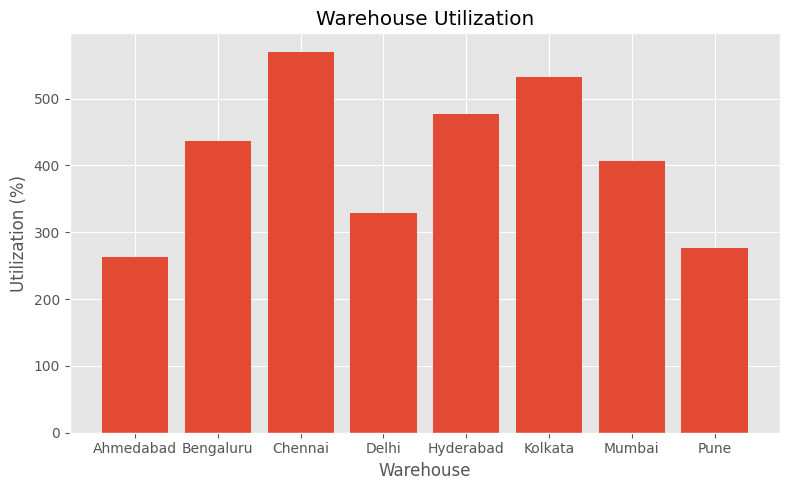


Business Insight: Chennai is the most utilized warehouse, while Ahmedabad has the lowest utilization.
Recommendation: Redistribute inventory from highly utilized warehouses to underutilized warehouses to improve operational efficiency.


In [20]:
warehouse_stock = (
    inventory
    .merge(warehouses, on="warehouse_id")
    .groupby(["warehouse_city", "capacity"])
    .agg(
        Total_Stock=("stock_qty", "sum")
    )
    .reset_index()
)

warehouse_stock["Utilization (%)"] = (
    warehouse_stock["Total_Stock"]
    / warehouse_stock["capacity"]
) * 100

display(warehouse_stock)

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_stock["warehouse_city"],
    warehouse_stock["Utilization (%)"]
)

plt.title("Warehouse Utilization")
plt.xlabel("Warehouse")
plt.ylabel("Utilization (%)")

plt.tight_layout()

plt.show()

highest = warehouse_stock.loc[
    warehouse_stock["Utilization (%)"].idxmax(),
    "warehouse_city"
]

lowest = warehouse_stock.loc[
    warehouse_stock["Utilization (%)"].idxmin(),
    "warehouse_city"
]

print(
    f"\nBusiness Insight: {highest} is the most utilized warehouse, while {lowest} has the lowest utilization."
)

print(
    "Recommendation: Redistribute inventory from highly utilized warehouses to underutilized warehouses to improve operational efficiency."
)

,warehouse_city,capacity,Total_Stock,Utilization (%)
0,Ahmedabad,16452,43339,263.426939
1,Bengaluru,10924,47717,436.808861
2,Chennai,7945,45231,569.301447
3,Delhi,14593,48074,329.431919
4,Hyderabad,9911,47313,477.378670
5,Kolkata,9070,48234,531.797133
6,Mumbai,12424,50472,406.245976
7,Pune,18015,49909,277.041354


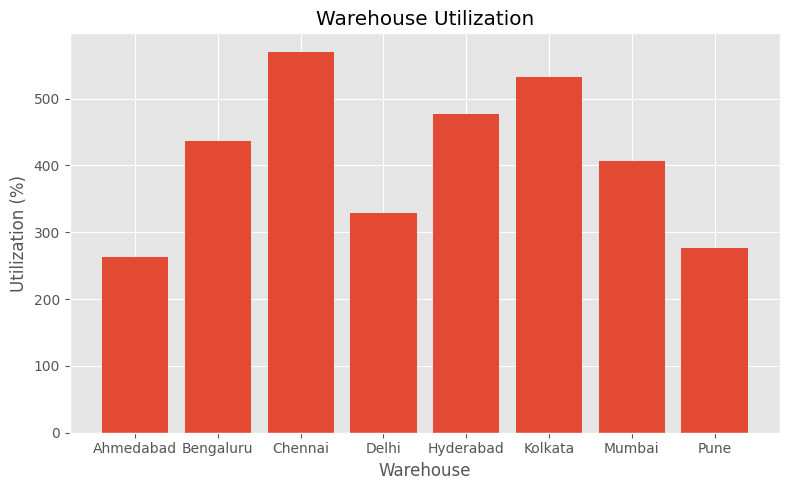


Business Insight: Chennai is the most utilized warehouse, while Ahmedabad has the lowest utilization.
Recommendation: Redistribute inventory from highly utilized warehouses to underutilized warehouses to improve operational efficiency.


In [21]:
warehouse_stock = (
    inventory
    .merge(warehouses, on="warehouse_id")
    .groupby(["warehouse_city", "capacity"])
    .agg(
        Total_Stock=("stock_qty", "sum")
    )
    .reset_index()
)

warehouse_stock["Utilization (%)"] = (
    warehouse_stock["Total_Stock"]
    / warehouse_stock["capacity"]
) * 100

display(warehouse_stock)

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_stock["warehouse_city"],
    warehouse_stock["Utilization (%)"]
)

plt.title("Warehouse Utilization")
plt.xlabel("Warehouse")
plt.ylabel("Utilization (%)")

plt.tight_layout()

plt.show()

highest = warehouse_stock.loc[
    warehouse_stock["Utilization (%)"].idxmax(),
    "warehouse_city"
]

lowest = warehouse_stock.loc[
    warehouse_stock["Utilization (%)"].idxmin(),
    "warehouse_city"
]

print(
    f"\nBusiness Insight: {highest} is the most utilized warehouse, while {lowest} has the lowest utilization."
)

print(
    "Recommendation: Redistribute inventory from highly utilized warehouses to underutilized warehouses to improve operational efficiency."
)

### Q6. Which shipping mode is the most cost-effective?

,Average_Shipping_Cost,Total_Shipments
shipping_mode,,
Rail,27.184127,3378
Air,27.487537,3269
Road,27.756016,3353


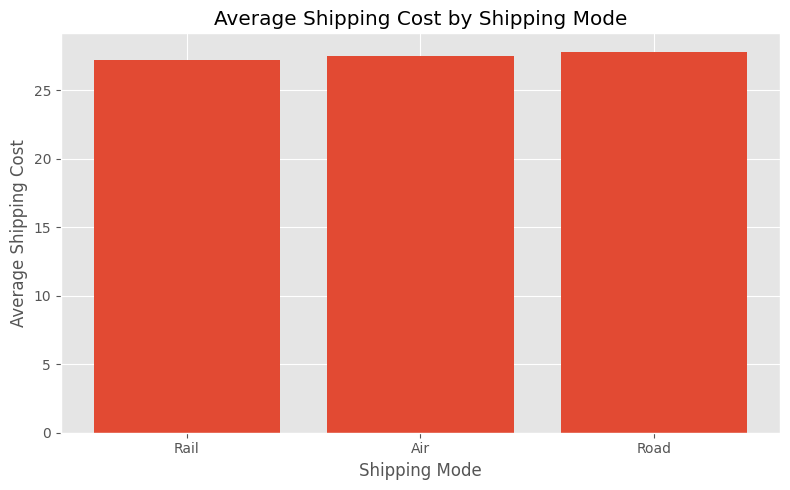


Business Insight: 'Rail' has the lowest average shipping cost.
Recommendation: Prioritize this shipping mode wherever service quality is maintained.


In [23]:
shipping_analysis = (
    shipments
    .groupby("shipping_mode")
    .agg(
        Average_Shipping_Cost=("shipping_cost", "mean"),
        Total_Shipments=("shipment_id", "count")
    )
    .sort_values("Average_Shipping_Cost")
)

display(shipping_analysis)

plt.figure(figsize=(8,5))

plt.bar(
    shipping_analysis.index,
    shipping_analysis["Average_Shipping_Cost"]
)

plt.title("Average Shipping Cost by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Cost")

plt.tight_layout()
plt.show()

best_mode = shipping_analysis.index[0]

print(f"\nBusiness Insight: '{best_mode}' has the lowest average shipping cost.")

print("Recommendation: Prioritize this shipping mode wherever service quality is maintained.")

### Q7. Which products have the highest return impact?

,Returned_Quantity
product_name,
Product_9,122
Product_60,118
Product_88,103
Product_46,101
Product_71,93
Product_6,93
Product_43,91
Product_58,91
Product_15,88


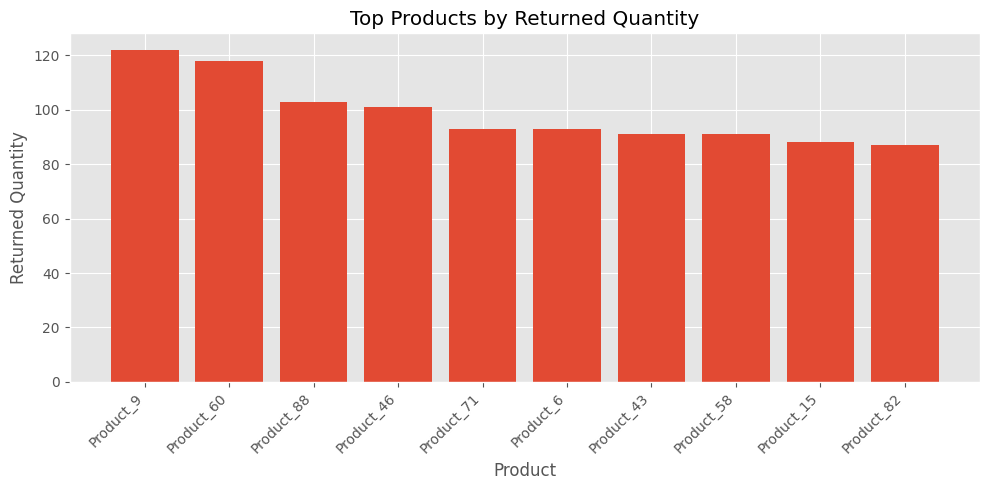


Business Insight: 'Product_9' has the highest return quantity.
Recommendation: Review product quality, packaging, and supplier performance for this product.


In [25]:
return_impact = (
    returns
    .merge(orders[["order_id","product_id"]], on="order_id")
    .merge(products[["product_id","product_name"]], on="product_id")
    .groupby("product_name")
    .agg(
        Returned_Quantity=("returned_qty","sum")
    )
    .sort_values("Returned_Quantity", ascending=False)
    .head(10)
)

display(return_impact)

plt.figure(figsize=(10,5))

plt.bar(
    return_impact.index,
    return_impact["Returned_Quantity"]
)

plt.title("Top Products by Returned Quantity")
plt.xlabel("Product")
plt.ylabel("Returned Quantity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print(f"\nBusiness Insight: '{return_impact.index[0]}' has the highest return quantity.")

print("Recommendation: Review product quality, packaging, and supplier performance for this product.")

### Q8. Which return reason should the business address first?

,Total_Returns
return_reason,
Late Delivery,274
Damaged,269
Wrong Item,259


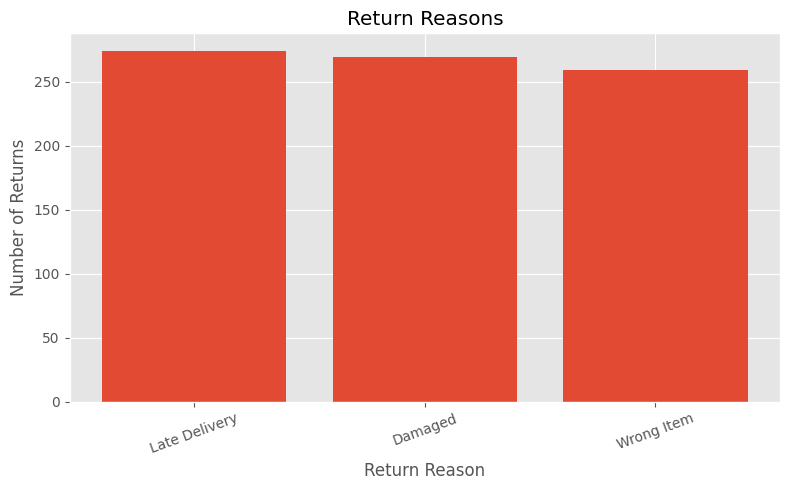


Business Insight: 'Late Delivery' is the leading reason for returns.
Recommendation: Investigate the root cause of this issue and implement corrective actions to reduce future returns.


In [27]:
return_reason_summary = (
    returns["return_reason"]
    .value_counts()
    .to_frame(name="Total_Returns")
)

display(return_reason_summary)

plt.figure(figsize=(8,5))

plt.bar(
    return_reason_summary.index,
    return_reason_summary["Total_Returns"]
)

plt.title("Return Reasons")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

top_reason = return_reason_summary.index[0]

print(f"\nBusiness Insight: '{top_reason}' is the leading reason for returns.")

print("Recommendation: Investigate the root cause of this issue and implement corrective actions to reduce future returns.")

# Block 4 - Executive Summary

This section summarizes the most important business findings and strategic recommendations derived from the analysis.

### Q9. What are the Top 5 Business Insights?

In [30]:
print("=" * 70)
print("TOP 5 BUSINESS INSIGHTS")
print("=" * 70)

print(f"1. Highest Revenue Product           : {product_revenue.index[0]}")

print(f"2. Highest Revenue Category          : {category_revenue.index[0]}")

print(f"3. Highest Revenue Customer Segment  : {segment_revenue.index[0]}")

print(f"4. Most Cost Effective Shipping Mode : {shipping_analysis.index[0]}")

print(f"5. Overall Return Rate               : {return_rate:.2f}%")

TOP 5 BUSINESS INSIGHTS
1. Highest Revenue Product           : Product_68
2. Highest Revenue Category          : Sports
3. Highest Revenue Customer Segment  : Retail
4. Most Cost Effective Shipping Mode : Rail


NameError: name 'return_rate' is not defined

### Q10. What are the Top 5 Business Recommendations?

In [32]:
recommendations = pd.DataFrame({
    "Priority":[1,2,3,4,5],
    "Recommendation":[
        "Increase inventory for high revenue products.",
        "Focus marketing on the highest revenue customer segment.",
        "Prioritize the most cost-effective shipping mode whenever possible.",
        "Review products with the highest return quantity to reduce return rates.",
        "Balance inventory across warehouses to improve utilization."
    ]
})

display(recommendations)

,Priority,Recommendation
0,1,Increase inventory for high revenue products.
1,2,Focus marketing on the highest revenue custome...
2,3,Prioritize the most cost-effective shipping mo...
3,4,Review products with the highest return quanti...
4,5,Balance inventory across warehouses to improve...


## Project Conclusion

This project demonstrates a complete supply chain analytics workflow using Python and Pandas. The analysis covered data preparation, exploratory data analysis, and business decision-making to identify revenue opportunities, inventory improvements, logistics optimization, and customer return patterns.

The insights generated from this project can support operational planning and serve as the foundation for an interactive Power BI dashboard and SQL-based business reporting.